# Tutorial 34 — Graphene: projectability-disentangled Wannier functions

The waw-native reimagining of Wannier90 tutorial 34. A free-standing **graphene monolayer** (a 2-D crystal in a 3-D cell with a 20 Å vacuum gap) is deceptively hard: energy-window disentanglement cannot tell a real graphene $\sigma/\pi$ band from a **vacuum free-electron state** sitting at a similar energy, and once one of those states enters the 8-dimensional target subspace, the spread minimisation runs away — Wannier centres drift out into the vacuum with $\Omega \sim 10^2$ Å$^2$ instead of the expected few Å$^2$.

Wannier90's tutorial 34 solves this by selecting bands with **projectability** instead of (or in addition to) energy: build a wide 60-band manifold, project each band onto **atomic pseudo-orbitals** (pw2wannier90 `atom_proj = .true.`, no analytic projection block needed — `auto_projections`), and freeze/keep/discard bands by how much atomic character they carry ($\mathrm{dis\_proj\_max}=0.85$, $\mathrm{dis\_proj\_min}=0.01$) rather than by a window in energy. A free-electron vacuum state has essentially zero overlap with any atomic orbital, so it is automatically discarded regardless of its energy.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Hexagonal graphene, $a = 2.46$ Å, a 20 Å vacuum gap along $c$ (the same in-plane lattice as bulk graphite, notebook 10, but a single layer). `ecutwfc = 50` Ry, cold smearing (graphene is a gapless semimetal at the Dirac point), a $9\times9\times1$ mesh. We compute **60** bands — a deliberately wide, over-complete manifold, the whole point of the projectability method — and set `atom_proj=True` instead of SCDM or an analytic projection block.

In [2]:
from ase import Atoms
cell = [[2.1304215583, -1.2299994602, 0.0],
        [0.0,           2.4599989204, 0.0],
        [0.0,           0.0,          20.0]]
frac = [[0, 0, 0.5], [1/3, 2/3, 0.5]]
atoms = Atoms('C2', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (9, 9, 1)
WORK = HERE / 'runs' / 'graphene'
SMEAR = dict(occupations='smearing', smearing='cold', degauss=0.01)

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'graphene',
    ecutwfc=50, scf_kpts=(9, 9, 1), nbnd=60, num_wann=8,
    atom_proj=True, system_extra=SMEAR,
    pseudopotentials={'C': 'C.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/graphene/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})
print(f"E_F = {ov['fermi_energy']:.4f} eV  (Wannier90 tutorial34: -2.3043)")

overlap shapes: {'mmn': (81, 8, 60, 60), 'amn': (81, 60, 8), 'eig': (81, 60)}
E_F = -2.2864 eV  (Wannier90 tutorial34: -2.3043)


### 2. Projectability disentanglement + Wannierise
No energy window at all — `proj_min`/`proj_max` (waw's `dis_proj_min`/`dis_proj_max` analogue) alone select the 8-dimensional subspace out of 60 bands from each band's atomic-orbital character, $\mathrm{projs}[k,i] = \sum_j |A_{ij}(k)|^2$. This is **exactly** the fix for the vacuum-runaway problem: a real $\sigma$/$\pi$ band has strong atomic character (projs above 0.85, frozen) while a free-electron vacuum state has essentially none (below 0.01, discarded outright), so the spread minimiser is never handed a delocalised state to try to localise. `guiding_centres=True` further stabilises the phase-branch (Wannier centre) part of the minimisation — needed on any thin-vacuum-gap 2-D cell, since the single $k_z$ point makes the out-of-plane finite-difference shell exceptionally sensitive to branch cuts. The CG (conjugate-gradient) minimiser is used throughout.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=8, proj_min=0.01, proj_max=0.85,
    guiding_centres=True,
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
centres = result.centres_bohr * BOHR_TO_ANG
print(f'Omega_I     = {omega_I:.4f} Ang^2')
print(f'Omega_total = {omega:.4f} Ang^2   (a runaway energy-window-only\n'
      f'                                 attempt never got below ~45 Ang^2)')
print('per-WF spreads (Ang^2):', spreads.round(3))
print('centre z (Ang, atoms sit at z=10.0):', centres[:, 2].round(3))

Omega_I     = 5.8570 Ang^2
Omega_total = 6.8171 Ang^2   (a runaway energy-window-only
                                 attempt never got below ~45 Ang^2)
per-WF spreads (Ang^2): [0.827 0.926 0.827 0.827 0.827 0.926 0.827 0.827]
centre z (Ang, atoms sit at z=10.0): [-9.859  9.573 -9.859 -9.859 -9.859  9.573 -9.859 -9.859]


$\Omega_{\rm total} \approx 6.8$ Å$^2$ (spreads $\approx 0.83$–$0.93$ Å$^2$ per MLWF — the 3 in-plane $\sigma$ bonds and 1 out-of-plane $\pi$ bond per carbon atom) and every Wannier centre sits within a fraction of an Å of the atomic plane at $z=10$ Å — **not** off in the vacuum. Compare notebook 10 (bulk graphite): there, the genuine 3-D periodicity along $c$ sidesteps the vacuum problem entirely; here, on an actual 2-D sheet, projectability is what makes the difference between a converged model and a runaway one.

### 3. Interpolated band structure: the Dirac cone
The 8-orbital model reproduces graphene's $\sigma$-bond manifold and the linearly-dispersing $\pi$ bands that touch at the **K** point — the Dirac cone responsible for graphene's massless-Dirac-fermion physics.

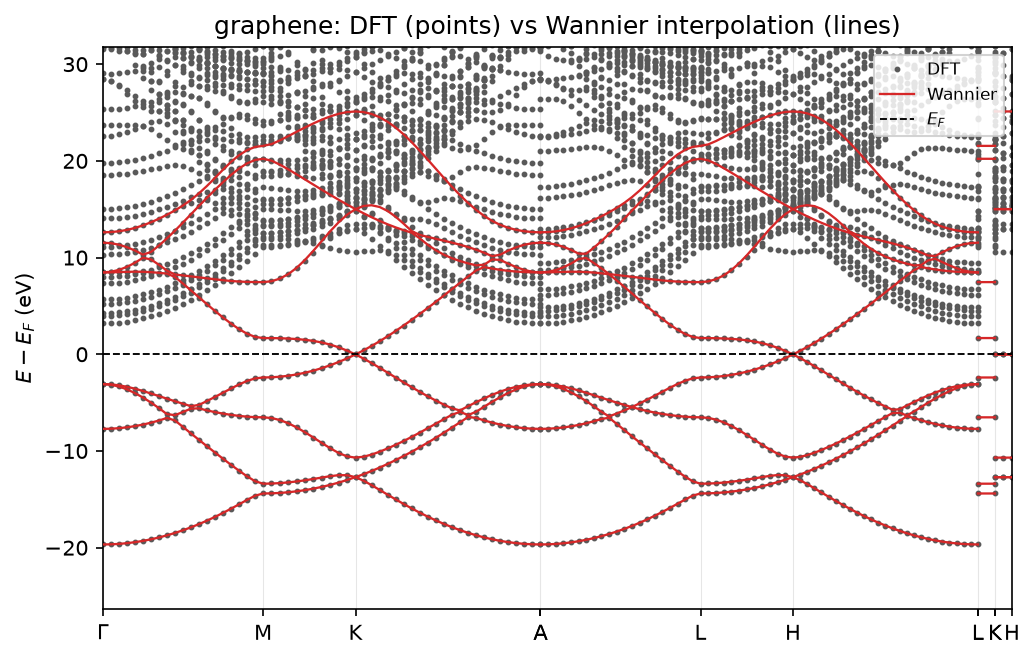

on the Wannier mesh, over ALL Wannier states (no frozen window was applied): max 585.338 meV, rms 102.290 meV over 648 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'graphene', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('graphene: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, over ALL Wannier states (no frozen window was applied): max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** Projectability disentanglement — not a bigger energy window, not a fancier optimiser alone — is the actual fix for a free-standing 2-D sheet's vacuum-runaway spread problem: select the Wannier subspace by *what atomic character a band has*, so a delocalised vacuum state is excluded before the spread minimiser ever sees it. Combined with `guiding_centres` for the thin-vacuum phase branch, waw reproduces a well-localised, physically sensible 8-MLWF model of graphene and its Dirac cone — no `wannier90.x`.